Fetch Data from Yfinance

In [5]:
import yfinance as yf
import pandas as pd

snp_ticker = "^SPX"

snp = yf.Ticker(snp_ticker)

hist = snp.history(period="6mo")  

df = hist.reset_index()

print(df.head())

df.to_csv("/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/stock_portfolio_selection/snp_data.csv", index=False)

                       Date         Open         High          Low  \
0 2024-04-16 00:00:00-04:00  5064.589844  5079.839844  5039.830078   
1 2024-04-17 00:00:00-04:00  5068.970215  5077.959961  5007.250000   
2 2024-04-18 00:00:00-04:00  5031.520020  5056.660156  5001.890137   
3 2024-04-19 00:00:00-04:00  5005.439941  5019.020020  4953.560059   
4 2024-04-22 00:00:00-04:00  4987.330078  5038.839844  4969.399902   

         Close      Volume  Dividends  Stock Splits  
0  5051.410156  4006200000        0.0           0.0  
1  5022.209961  3596130000        0.0           0.0  
2  5011.120117  3619760000        0.0           0.0  
3  4967.229980  3878750000        0.0           0.0  
4  5010.600098  3820250000        0.0           0.0  


Chart for SnP 500

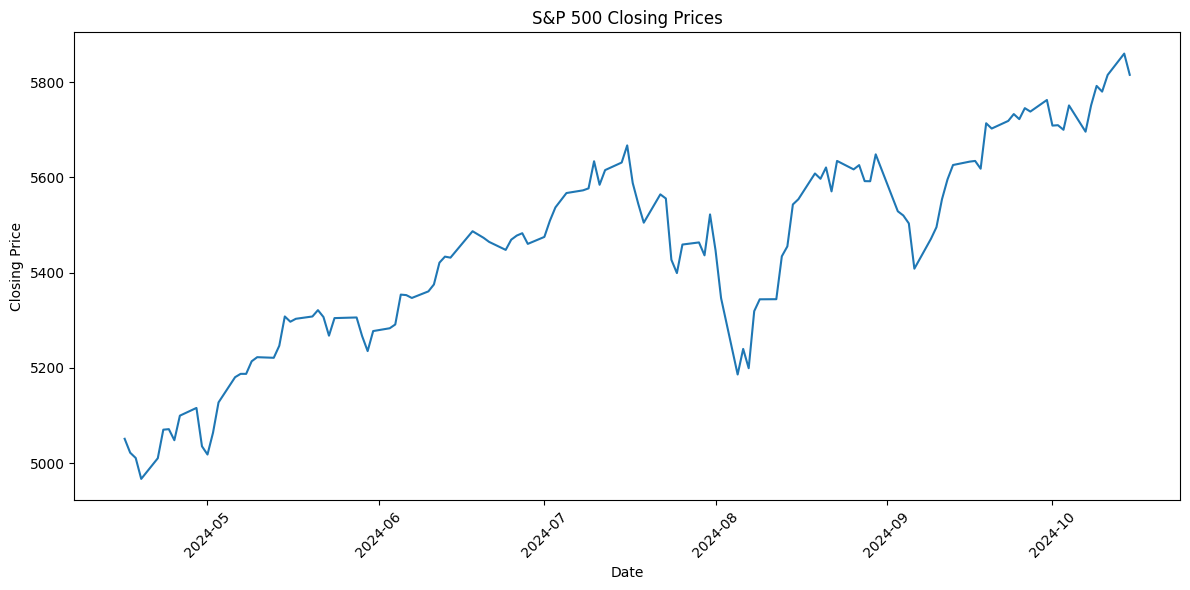

                       Date         Open         High          Low  \
0 2024-04-16 00:00:00-04:00  5064.589844  5079.839844  5039.830078   
1 2024-04-17 00:00:00-04:00  5068.970215  5077.959961  5007.250000   
2 2024-04-18 00:00:00-04:00  5031.520020  5056.660156  5001.890137   
3 2024-04-19 00:00:00-04:00  5005.439941  5019.020020  4953.560059   
4 2024-04-22 00:00:00-04:00  4987.330078  5038.839844  4969.399902   

         Close      Volume  Dividends  Stock Splits  
0  5051.410156  4006200000        0.0           0.0  
1  5022.209961  3596130000        0.0           0.0  
2  5011.120117  3619760000        0.0           0.0  
3  4967.229980  3878750000        0.0           0.0  
4  5010.600098  3820250000        0.0           0.0  


<Figure size 640x480 with 0 Axes>

In [7]:

import matplotlib.pyplot as plt

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'])
plt.title('S&P 500 Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

plt.savefig('/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/stock_portfolio_selection/snp_plot.png')

print(df.head())

SnP 500 Moving Averages and Trading Signals

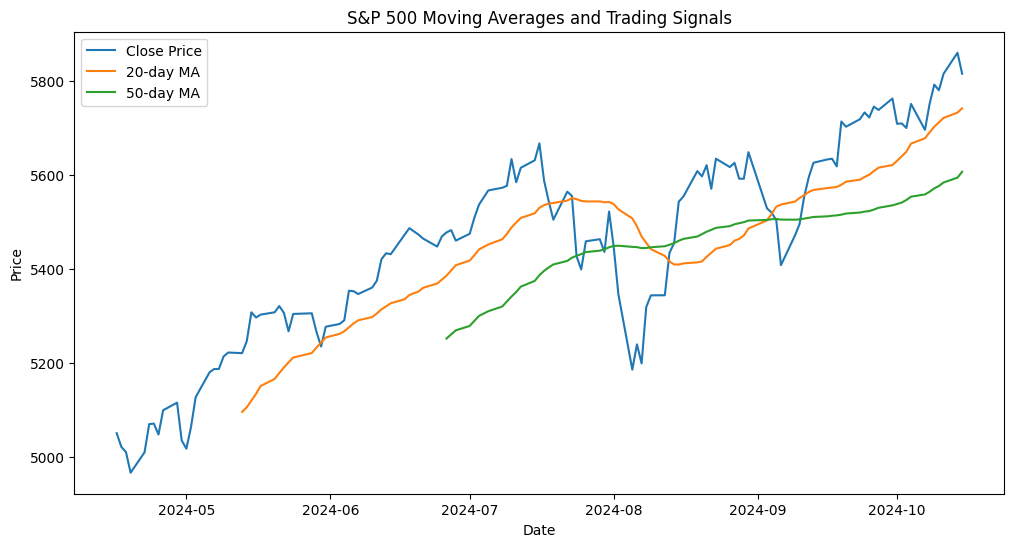

Number of buy signals: 61
Number of sell signals: 17


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already loaded with 6 months of data
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Generate trading signals
df['Signal'] = 0
df.loc[df['MA20'] > df['MA50'], 'Signal'] = 1
df.loc[df['MA20'] < df['MA50'], 'Signal'] = -1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA20'], label='20-day MA')
plt.plot(df['Date'], df['MA50'], label='50-day MA')
plt.title('S&P 500 Moving Averages and Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Print number of buy and sell signals
print("Number of buy signals:", (df['Signal'] == 1).sum())
print("Number of sell signals:", (df['Signal'] == -1).sum())

SnP 500 Volatility Analysis

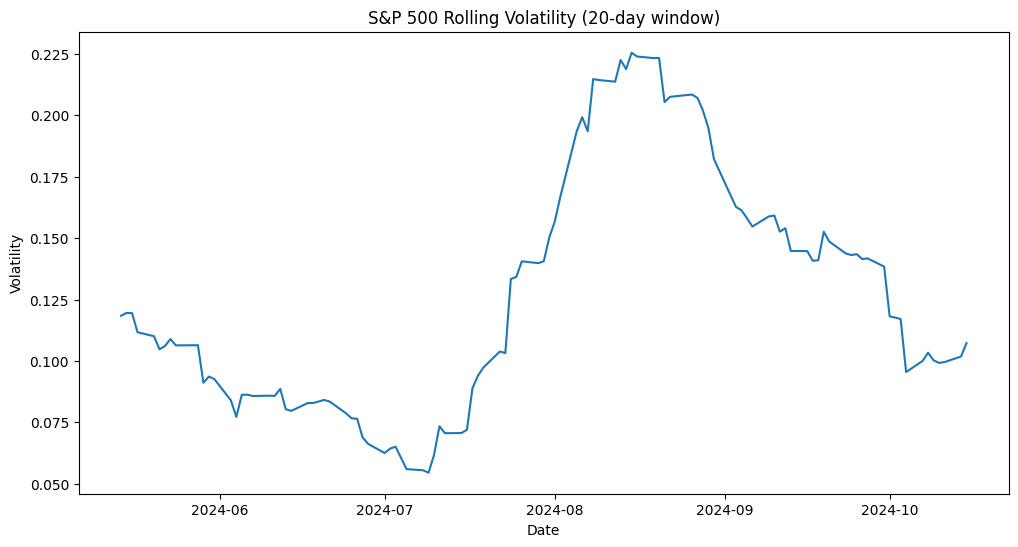

Average volatility over the period: 0.1272
Maximum volatility: 0.2254
Minimum volatility: 0.0545


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Calculate rolling volatility (20-day window)
df['Volatility'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)  # Annualized

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'])
plt.title('S&P 500 Rolling Volatility (20-day window)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# Print average volatility
print(f"Average volatility over the period: {df['Volatility'].mean():.4f}")
print(f"Maximum volatility: {df['Volatility'].max():.4f}")
print(f"Minimum volatility: {df['Volatility'].min():.4f}")

Nifty 50 Trend Analysis using Linear Regression

In [10]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


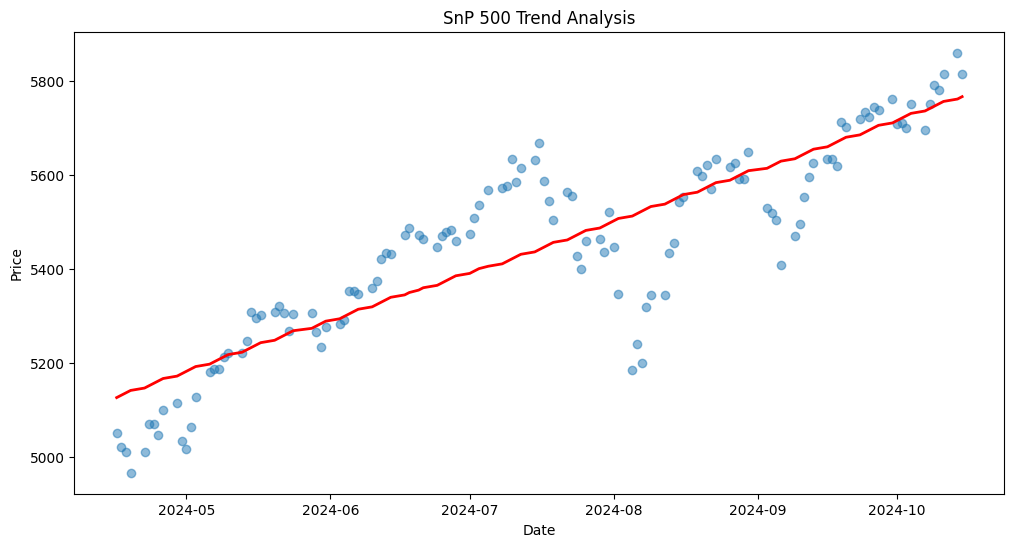

Trend slope: 5.0761
The overall trend is upward


In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create a numeric index for regression
df['Index'] = range(len(df))

# Fit linear regression
model = LinearRegression()
model.fit(df[['Index']], df['Close'])

# Generate predictions
df['Trend'] = model.predict(df[['Index']])

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(df['Date'], df['Close'], alpha=0.5)
plt.plot(df['Date'], df['Trend'], color='red', linewidth=2)
plt.title('SnP 500 Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Calculate and print the slope
slope = model.coef_[0]
print(f"Trend slope: {slope:.4f}")
if slope > 0:
    print("The overall trend is upward")
else:
    print("The overall trend is downward")

SnP 500 RSI Analysis

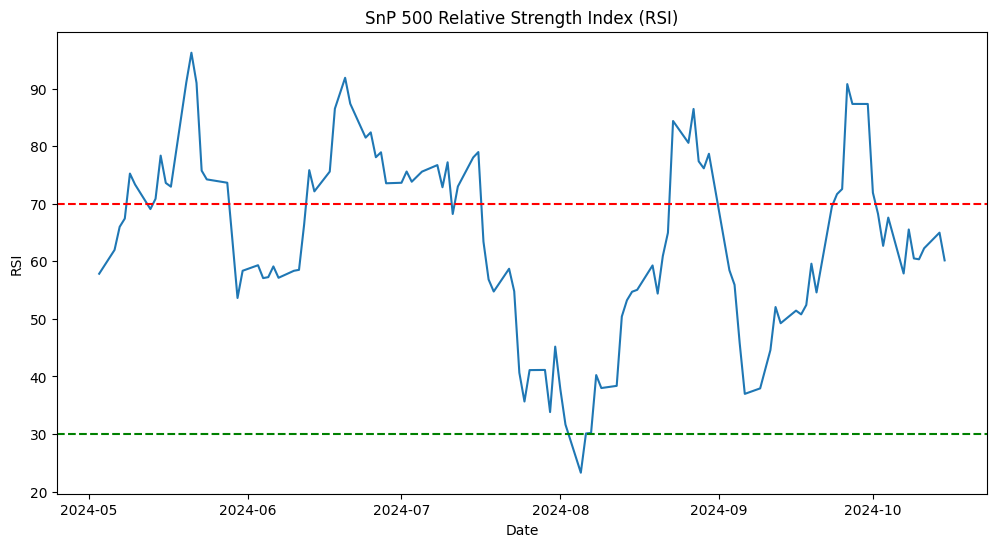

Number of overbought days: 45
Number of oversold days: 1


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Calculate RSI
df['RSI'] = calculate_rsi(df['Close'])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['RSI'])
plt.title('SnP 500 Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.axhline(y=70, color='r', linestyle='--')
plt.axhline(y=30, color='g', linestyle='--')
plt.show()

# Analyze overbought and oversold conditions
overbought = df[df['RSI'] > 70]
oversold = df[df['RSI'] < 30]

print(f"Number of overbought days: {len(overbought)}")
print(f"Number of oversold days: {len(oversold)}")

SnP 500 Correlation Analysis with Global Indices



In [11]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 8.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


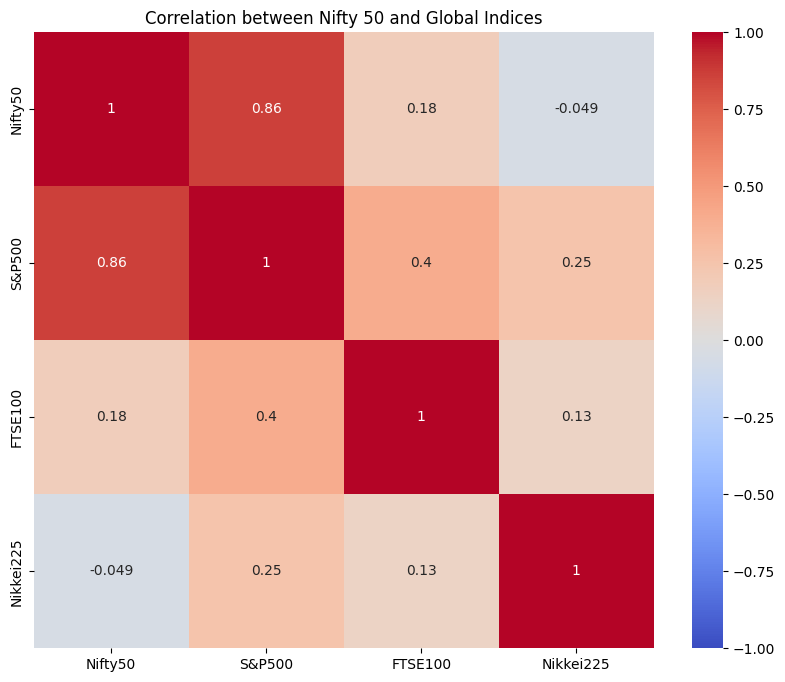

Correlation with Nifty 50:
Nifty50      1.000000
S&P500       0.861856
FTSE100      0.175440
Nikkei225   -0.048929
Name: Nifty50, dtype: float64


In [29]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fetch data for other indices
indices = {
    'Nifty50': '^NSEI',
    'S&P500': '^GSPC',
    'FTSE100': '^FTSE',
    'Nikkei225': '^N225'
}

data = {}
for name, ticker in indices.items():
    data[name] = yf.download(ticker, start=df['Date'].min(), end=df['Date'].max())['Close']

# Combine all data
combined_df = pd.DataFrame(data)

# Calculate correlation
correlation = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation between S&P 500 and Global Indices')
plt.show()

# Print correlation with Nifty 50
print("Correlation with Nifty 50:")
print(correlation['Nifty50'].sort_values(ascending=False))

Fetching data for S&P500
Fetching data for Nasdaq
Fetching data for DowJones
Fetching data for Nifty50
Fetching data for SENSEX
Fetching data for FTSE100
Fetching data for DAX
Fetching data for CAC40
Fetching data for Nikkei225
Fetching data for HSI
Fetching data for SSE
Fetching data for KOSPI
Fetching data for ASX200
Fetching data for TSX
Fetching data for BOVESPA
Fetching data for MOEX
Fetching data for SZSE
Fetching data for IBEX35
Fetching data for SWTSX
Fetching data for NIFTYBANK


/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_15673/2965781212.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df = combined_df.fillna(method='ffill')


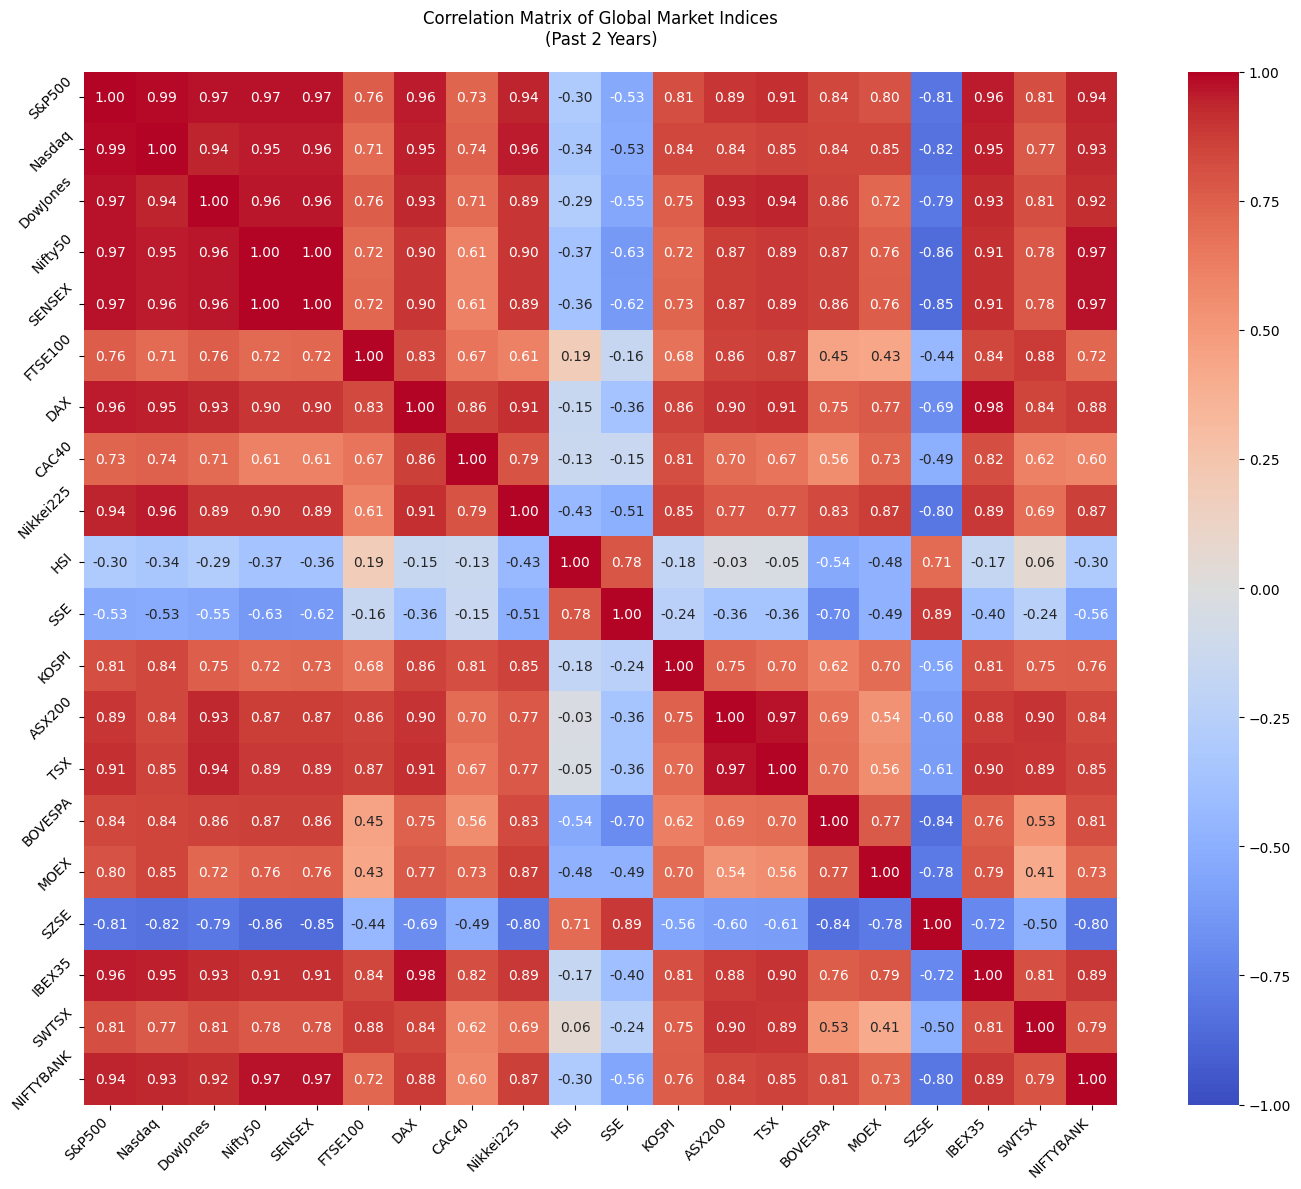


Average Correlation with Other Indices:
DAX            : 0.696
IBEX35         : 0.686
S&P500         : 0.681
Nasdaq         : 0.669
DowJones       : 0.668
TSX            : 0.664
ASX200         : 0.660
SENSEX         : 0.648
Nifty50        : 0.646
NIFTYBANK      : 0.641
Nikkei225      : 0.635
SWTSX          : 0.619
KOSPI          : 0.609
FTSE100        : 0.605
CAC40          : 0.573
BOVESPA        : 0.534
MOEX           : 0.522
HSI            : -0.069
SSE            : -0.236
SZSE           : -0.469

Annualized Volatility:
HSI            : 25.638%
SZSE           : 21.695%
Nikkei225      : 20.931%
Nasdaq         : 19.024%
KOSPI          : 16.918%
BOVESPA        : 15.984%
SSE            : 15.585%
NIFTYBANK      : 14.577%
S&P500         : 13.984%
CAC40          : 13.525%
IBEX35         : 13.373%
DAX            : 12.795%
MOEX           : 12.160%
DowJones       : 11.842%
SENSEX         : 11.535%
Nifty50        : 11.509%
SWTSX          : 11.298%
ASX200         : 11.277%
TSX            : 11.13

In [30]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Dictionary of major world indices and their tickers
indices = {
    'S&P500': '^GSPC',          # USA
    'Nasdaq': '^IXIC',          # USA
    'DowJones': '^DJI',         # USA
    'Nifty50': '^NSEI',         # India
    'SENSEX': '^BSESN',         # India
    'FTSE100': '^FTSE',         # UK
    'DAX': '^GDAXI',           # Germany
    'CAC40': '^FCHI',          # France
    'Nikkei225': '^N225',      # Japan
    'HSI': '^HSI',             # Hong Kong
    'SSE': '000001.SS',        # Shanghai
    'KOSPI': '^KS11',          # South Korea
    'ASX200': '^AXJO',         # Australia
    'TSX': '^GSPTSE',          # Canada
    'BOVESPA': '^BVSP',        # Brazil
    'MOEX': 'IMOEX.ME',        # Russia
    'SZSE': '399001.SZ',       # Shenzhen
    'IBEX35': '^IBEX',         # Spain
    'SWTSX': '^SSMI',          # Switzerland
    'NIFTYBANK': '^NSEBANK'    # India Banking Index
}

def fetch_and_analyze_indices():
    # Calculate date range (2 years of data)
    end_date = datetime.now()
    start_date = end_date - timedelta(days=2*365)
    
    # Fetch data for all indices
    print("Downloading data for indices...")
    data = {}
    for name, ticker in indices.items():
        try:
            print(f"Fetching data for {name}")
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)
            data[name] = df['Close']
        except Exception as e:
            print(f"Error downloading {name}: {str(e)}")
    
    # Combine all data
    combined_df = pd.DataFrame(data)
    
    # Remove any columns with all NaN values
    combined_df = combined_df.dropna(axis=1, how='all')
    
    # Forward fill any remaining NaN values
    combined_df = combined_df.fillna(method='ffill')
    
    # Calculate correlation
    correlation = combined_df.corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(15, 12))
    sns.heatmap(correlation, 
                annot=True, 
                cmap='coolwarm', 
                vmin=-1, 
                vmax=1, 
                center=0, 
                fmt='.2f',
                square=True)
    plt.title('Correlation Matrix of Global Market Indices\n(Past 2 Years)', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Calculate and display average correlation for each index
    avg_correlation = correlation.mean().sort_values(ascending=False)
    print("\nAverage Correlation with Other Indices:")
    print("=======================================")
    for idx, value in avg_correlation.items():
        print(f"{idx:<15}: {value:.3f}")
    
    # Calculate daily returns
    returns = combined_df.pct_change()
    
    # Calculate volatility (standard deviation of returns)
    volatility = returns.std() * (252 ** 0.5)  # Annualized volatility
    print("\nAnnualized Volatility:")
    print("=====================")
    for idx, value in volatility.sort_values(ascending=False).items():
        print(f"{idx:<15}: {value:.3%}")

    return combined_df, correlation


combined_df, correlation = fetch_and_analyze_indices()

Monte Carlo Simulation

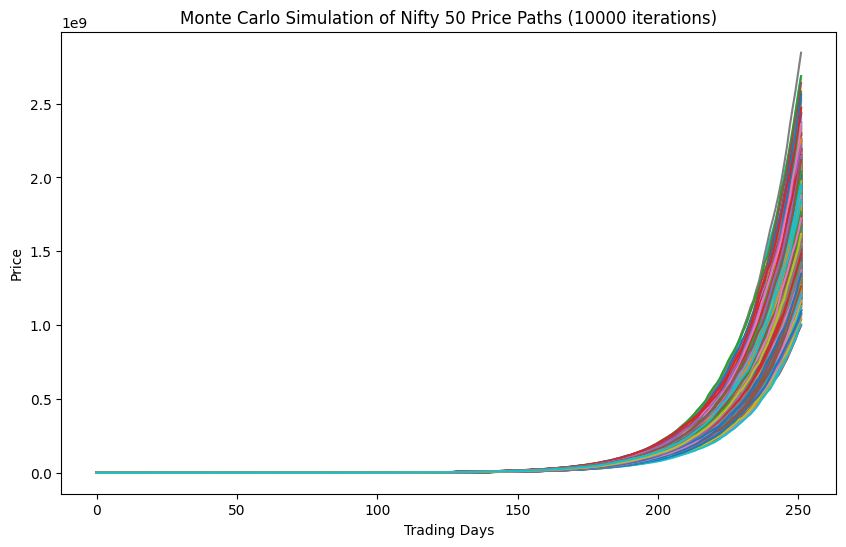

Predicted price after 252 trading days:
Mean: 1640481858.60
Max: 2844705751.83
Min: 995694836.04
Standard Deviation: 219481212.67

95% Confidence Interval:
Lower Bound: 1210306586.49
Upper Bound: 2070657130.71

99% Confidence Interval:
Lower Bound: 1075135719.44
Upper Bound: 2205827997.77


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming df is our DataFrame with Nifty 50 data

def monte_carlo_simulation(start_price, days, iterations, volatility, risk_free_rate):
    # Calculate daily returns
    daily_returns = np.exp(drift + volatility * norm.ppf(np.random.rand(days, iterations)))
    
    # Create price paths
    price_paths = np.zeros((days, iterations))
    price_paths[0] = start_price
    for t in range(1, days):
        price_paths[t] = price_paths[t-1] * daily_returns[t]
    
    return price_paths

# Calculate parameters
returns = df['Close'].pct_change().dropna()
days = 252  # Simulate for next 252 trading days (approximately 1 year)
iterations = 10000

volatility = returns.std()
risk_free_rate = 0.05  # Assume 5% risk-free rate, adjust as needed
S0 = df['Close'].iloc[-1]  # Last closing price

# Calculate drift
drift = risk_free_rate - 0.5 * volatility**2

# Run simulation
simulations = monte_carlo_simulation(S0, days, iterations, volatility, risk_free_rate)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(simulations)
plt.title(f'Monte Carlo Simulation of Nifty 50 Price Paths ({iterations} iterations)')
plt.xlabel('Trading Days')
plt.ylabel('Price')
plt.show()

# Calculate statistics
final_prices = simulations[-1, :]
mean_price = np.mean(final_prices)
max_price = np.max(final_prices)
min_price = np.min(final_prices)
std_dev = np.std(final_prices)

print(f"Predicted price after {days} trading days:")
print(f"Mean: {mean_price:.2f}")
print(f"Max: {max_price:.2f}")
print(f"Min: {min_price:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

# Calculate confidence intervals
confidence_intervals = {
    '95%': norm.interval(0.95, loc=mean_price, scale=std_dev),
    '99%': norm.interval(0.99, loc=mean_price, scale=std_dev)
}

for ci, interval in confidence_intervals.items():
    print(f"\n{ci} Confidence Interval:")
    print(f"Lower Bound: {interval[0]:.2f}")
    print(f"Upper Bound: {interval[1]:.2f}")

Monte Carlo Simulation for Price Prediction

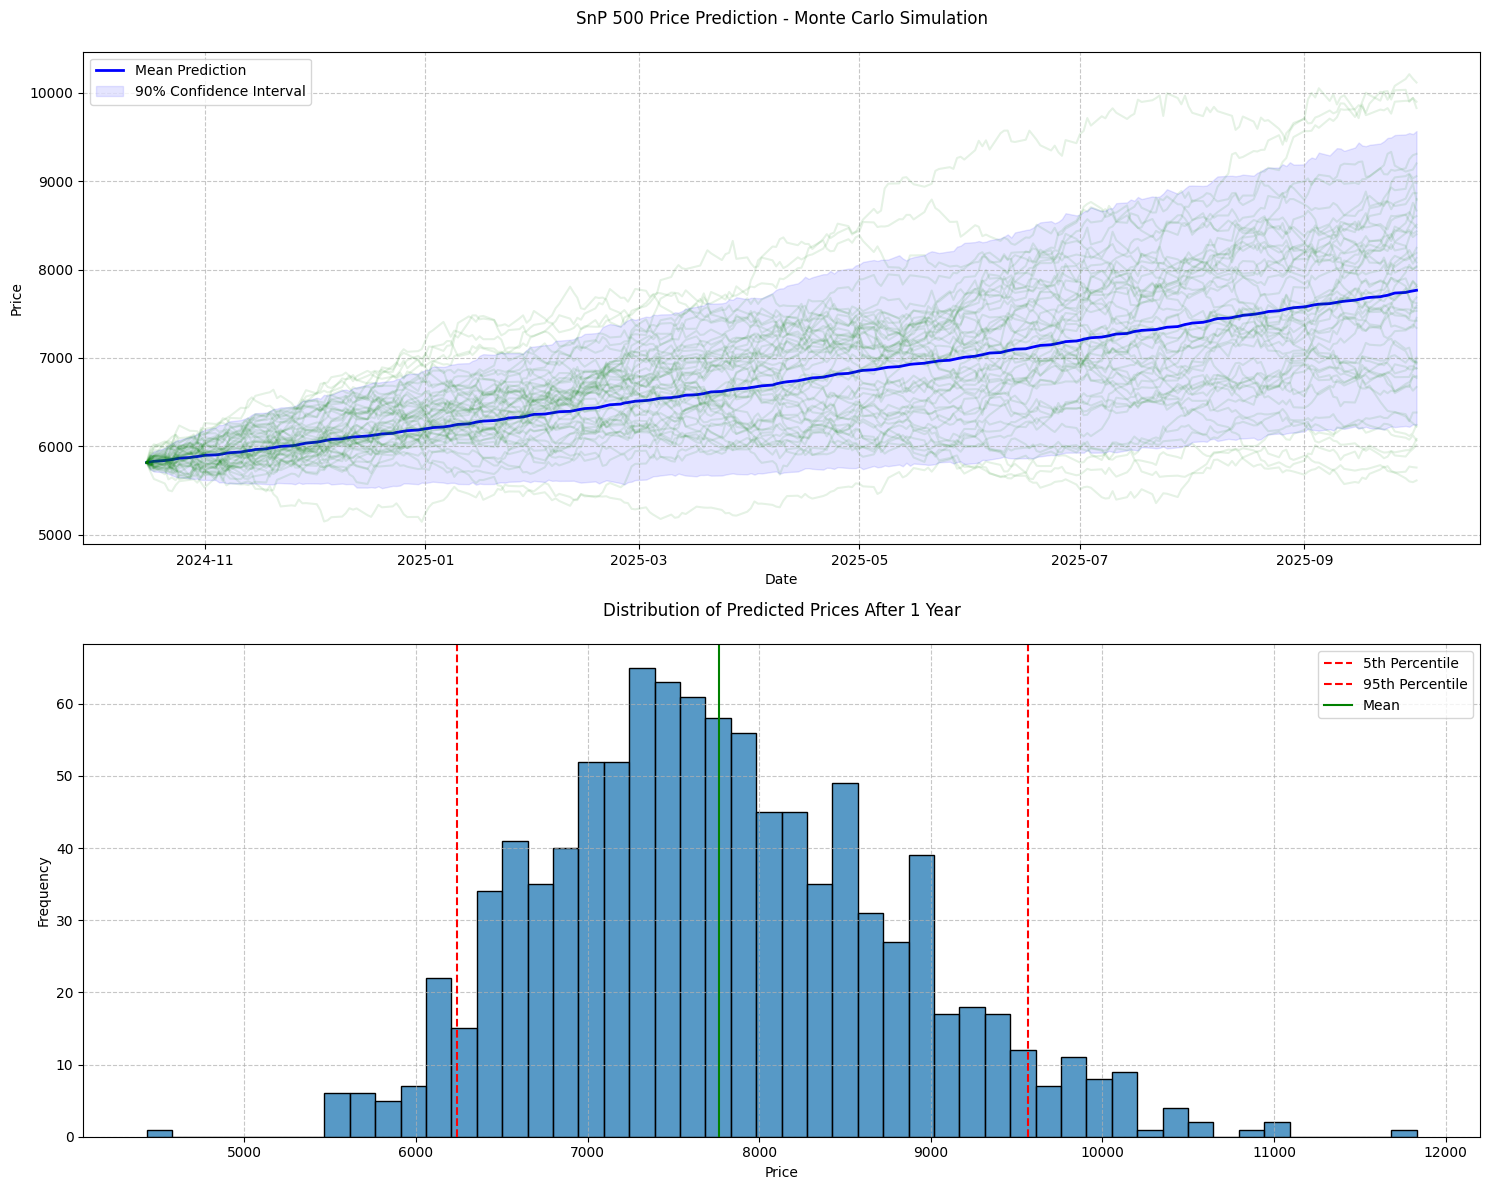


Monte Carlo Simulation Results

Initial Nifty 50 Price: ₹5,815.26

Predicted Price Statistics (After 1 Year):
Mean Price: ₹7,765.16
Median Price: ₹7,667.73
Standard Deviation: ₹1,013.57

Confidence Intervals:
90% CI: [₹6,241.66, ₹9,567.26]
95% CI: [₹6,060.82, ₹9,945.16]

Probability of Price Increase: 98.5%
Expected Annual Return: 33.5%

First few rows of predictions:
                       Date   Mean_Price     Upper_95      Lower_5
0 2024-10-16 00:00:00-04:00  5815.259766  5815.259766  5815.259766
1 2024-10-17 00:00:00-04:00  5821.787547  5904.742149  5737.496452
2 2024-10-18 00:00:00-04:00  5829.411837  5941.529538  5714.266745
3 2024-10-21 00:00:00-04:00  5839.065066  5979.605823  5705.669359
4 2024-10-22 00:00:00-04:00  5844.649614  6010.360109  5689.013639


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from datetime import datetime, timedelta

# Calculate daily returns and volatility
returns = np.log(1 + df['Close'].pct_change())
mu = returns.mean()
sigma = returns.std()

def predict_prices(S0, days, simulations):
    # Initialize price array
    prices = np.zeros((days, simulations))
    prices[0] = S0
    
    # Generate random walks
    for i in range(1, days):
        # Generate random numbers for simulation
        rand = np.random.standard_normal(simulations)
        # Calculate daily returns
        daily_returns = mu + sigma * rand
        # Calculate next day's price
        prices[i] = prices[i-1] * np.exp(daily_returns)
    
    return prices

# Set simulation parameters
S0 = df['Close'].iloc[-1]  # Last closing price
days = 252  # Trading days (1 year)
simulations = 1000

# Run simulation
predicted_prices = predict_prices(S0, days, simulations)

# Generate future dates for x-axis
if isinstance(df.index, pd.DatetimeIndex):
    last_date = df.index[-1]
else:
    # If the index is not datetime, convert the 'Date' column to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    last_date = df['Date'].iloc[-1]

# Create business days (excluding weekends)
future_dates = pd.date_range(start=last_date, periods=days+1, freq='B')[1:]

# Calculate statistics for each day
daily_stats = {
    'mean': np.mean(predicted_prices, axis=1),
    'std': np.std(predicted_prices, axis=1),
    'percentile_5': np.percentile(predicted_prices, 5, axis=1),
    'percentile_95': np.percentile(predicted_prices, 95, axis=1)
}

# Set the default matplotlib style
plt.style.use('default')

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Price Paths and Confidence Intervals
ax1.plot(future_dates, daily_stats['mean'], 'b-', label='Mean Prediction', linewidth=2)
ax1.fill_between(future_dates, 
                 daily_stats['percentile_5'], 
                 daily_stats['percentile_95'], 
                 color='blue', alpha=0.1, 
                 label='90% Confidence Interval')

# Plot only a subset of paths for better visualization
for i in range(50):  # Plot 50 sample paths
    ax1.plot(future_dates, predicted_prices[:, i], 'g-', alpha=0.1)

ax1.set_title('SnP 500 Price Prediction - Monte Carlo Simulation', fontsize=12, pad=20)
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Price', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: Final Price Distribution
final_prices = predicted_prices[-1, :]
sns.histplot(data=final_prices, bins=50, ax=ax2)
ax2.axvline(np.percentile(final_prices, 5), color='r', linestyle='--', 
            label='5th Percentile')
ax2.axvline(np.percentile(final_prices, 95), color='r', linestyle='--', 
            label='95th Percentile')
ax2.axvline(np.mean(final_prices), color='g', linestyle='-', 
            label='Mean')
ax2.set_title('Distribution of Predicted Prices After 1 Year', fontsize=12, pad=20)
ax2.set_xlabel('Price', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

# Print analysis results
print("\nMonte Carlo Simulation Results")
print("=" * 40)
print(f"\nInitial Nifty 50 Price: ₹{S0:,.2f}")
print("\nPredicted Price Statistics (After 1 Year):")
print(f"Mean Price: ₹{np.mean(final_prices):,.2f}")
print(f"Median Price: ₹{np.median(final_prices):,.2f}")
print(f"Standard Deviation: ₹{np.std(final_prices):,.2f}")

print("\nConfidence Intervals:")
print(f"90% CI: [₹{np.percentile(final_prices, 5):,.2f}, ₹{np.percentile(final_prices, 95):,.2f}]")
print(f"95% CI: [₹{np.percentile(final_prices, 2.5):,.2f}, ₹{np.percentile(final_prices, 97.5):,.2f}]")

# Calculate probability of price increase
prob_increase = np.mean(final_prices > S0) * 100
print(f"\nProbability of Price Increase: {prob_increase:.1f}%")

# Calculate returns
expected_return = ((np.mean(final_prices) - S0) / S0) * 100
print(f"Expected Annual Return: {expected_return:.1f}%")

# Save predictions to DataFrame
prediction_df = pd.DataFrame({
    'Date': future_dates,
    'Mean_Price': daily_stats['mean'],
    'Upper_95': daily_stats['percentile_95'],
    'Lower_5': daily_stats['percentile_5']
})

# Display first few rows of predictions
print("\nFirst few rows of predictions:")
print(prediction_df.head().to_string())